# RPY hydrodynamics implementation tests

### Two spheres mobilities

* From [2006-reichert-phdth], Section 2.4.5.

Two spheres of radius $a = 1$ placed in the z direction with center to center distances $r$ (in units of $a$).


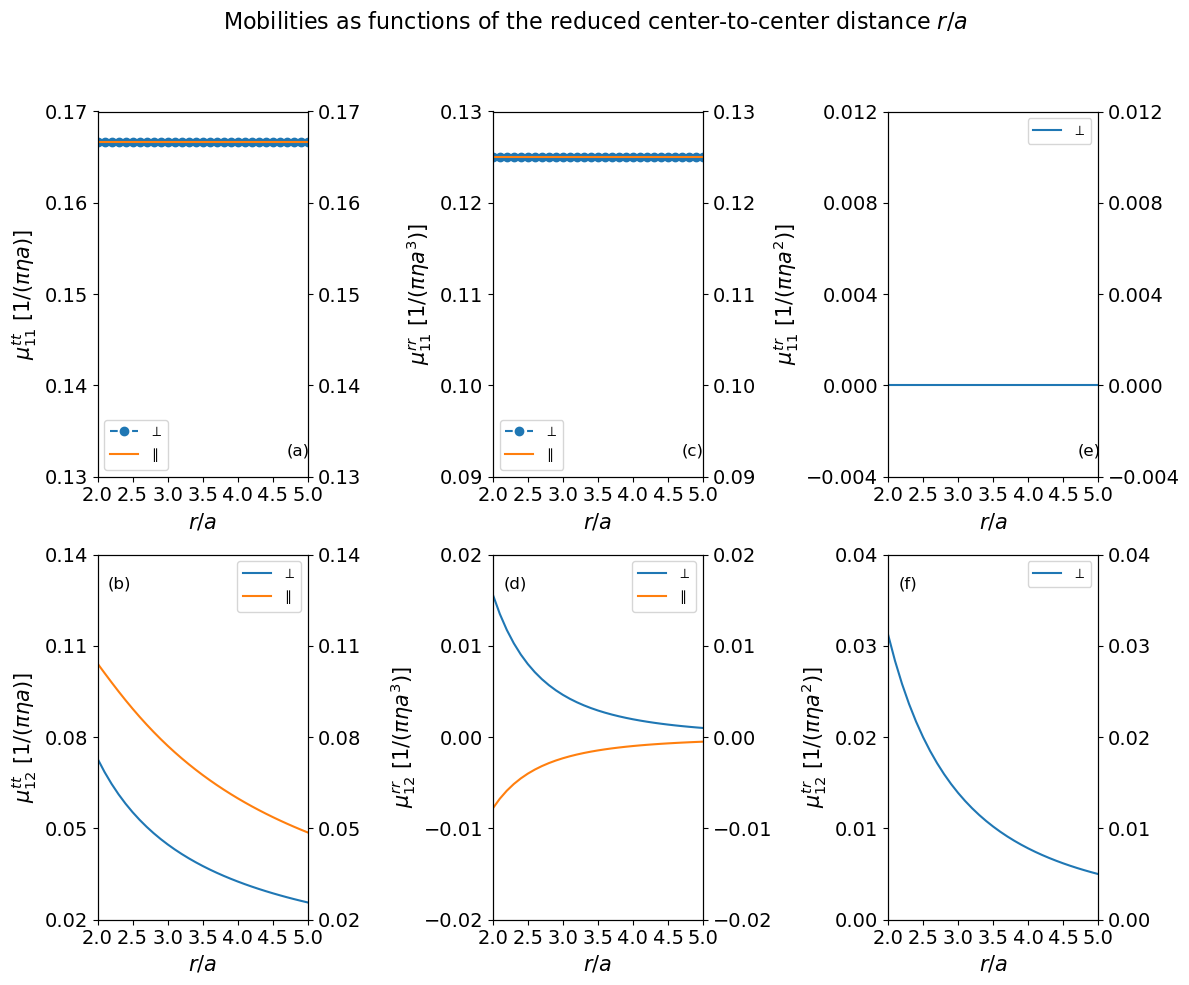

In [1]:
#The mobilities and velocities are no longer dumped by default in the core 
#Source code Oseen_RPY.cpp need to be altered to perform this sim

open("tensor_analysis_file.csv", "w").close()

import espressomd
import numpy as np
import json
import os

def load_diffusion_tensors(filename="tensor_analysis_file.csv"):
    tensors = []
    current = []

    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith("#"):
                if current:
                    tensors.append(np.array(current, dtype=float))
                    current = []
            else:
                current.append([float(x) for x in line.split(",")])

        if current:
            tensors.append(np.array(current, dtype=float))

    return tensors
 
system = espressomd.System(box_l = [10.0, 10.0, 10.0])
system.time_step = 0.000001 
system.cell_system.skin = 0.1
 
"""Setup for Brownian mechanics"""
 
system.thermostat.set_brownian(kT = 0.0, gamma = 6.0, gamma_rotation = 8.0, seed = 1)
system.integrator.set_brownian_dynamics(2.0)

rs = [2.0 + 0.1 * i for i in range(int((5.0 - 2.0) / 0.1) + 1)]
 
for r in rs:
    
    system.part.add(pos = [0.0, 0.0, 0.0])
    system.part.add(pos = [0.0, 0.0, r])
    system.integrator.run(1)
    system.part.clear()

tensors = load_diffusion_tensors()

mtt12zz = []
mtt12xx = []
mrr12zz = []
mrr12xx = []
mtr12xy = []
mtt11xx = []
mtt11zz = []
mrr11xx = []
mrr11zz = []
mtr11xy = []

for M in tensors:
    
    mtt12xx.append(M[0, 3])
    mtt12zz.append(M[2, 5])
    mrr12zz.append(M[6, 9])
    mrr12xx.append(M[8, 11])
    mtr12xy.append(M[0, 10])
    mtt11xx.append(M[0, 0])
    mtt11zz.append(M[2, 2])
    mrr11xx.append(M[6, 6])
    mrr11zz.append(M[8, 8])
    mtr11xy.append(M[0, 7])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 10), sharex=False)

fig.suptitle(
    r"Mobilities as functions of the reduced center-to-center distance $r/a$",
    fontsize=16
)

ax = axes[0, 0]
ax.plot(rs, mtt11xx, label=r"$\perp$", linestyle="--", marker="o")
ax.plot(rs, mtt11zz, label=r"$\parallel$")
ax.legend()
ax.text(0.90, 0.05, "(a)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(0.13, 0.17)
ax.set_xlim(2., 5.)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{11}^{tt}$ [1/($\pi \eta a$)]", fontsize=15)
ax.set_yticks([0.13, 0.14, 0.15, 0.16, 0.17])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax2 = ax.twinx()
ax2.set_ylim(0.13, 0.17)
ax2.set_yticks([0.13, 0.14, 0.15, 0.16, 0.17])
ax2.tick_params(axis="both", labelsize=14)

ax = axes[0, 1]
ax.plot(rs, mrr11xx, label=r"$\perp$", linestyle="--", marker="o")
ax.plot(rs, mrr11zz, label=r"$\parallel$")
ax.legend()
ax.text(0.90, 0.05, "(c)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(0.09, 0.13)
ax.set_xlim(2., 5.)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{11}^{rr}$ [1/($\pi \eta a^3$)]", fontsize=15)
ax.set_yticks([0.09, 0.10, 0.11, 0.12, 0.13])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax2 = ax.twinx()
ax2.set_ylim(0.09, 0.13)
ax2.set_yticks([0.09, 0.10, 0.11, 0.12, 0.13])
ax2.tick_params(axis="both", labelsize=14)

ax = axes[0, 2]
ax.plot(rs, mtr11xy, label=r"$\perp$")
ax.legend()
ax.text(0.90, 0.05, "(e)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(-0.004, 0.012)
ax.set_xlim(2., 5.)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{11}^{tr}$ [1/($\pi \eta a^2$)]", fontsize=15)
ax.set_yticks([-0.004, 0.000, 0.004, 0.008, 0.012])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax2 = ax.twinx()
ax2.set_ylim(-0.004, 0.012)
ax2.set_yticks([-0.004, 0.000, 0.004, 0.008, 0.012])
ax2.tick_params(axis="both", labelsize=14)

ax = axes[1, 0]
ax.plot(rs, mtt12xx, label=r"$\perp$")
ax.plot(rs, mtt12zz, label=r"$\parallel$")
ax.text(0.05, 0.90, "(b)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(0.02, 0.14)
ax.set_xlim(2., 5.)
ax.set_yticks([0.02, 0.05, 0.08, 0.11, 0.14])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax.legend()
ax2 = ax.twinx()
ax2.set_ylim(0.02, .14)
ax2.set_yticks([0.02, 0.05, 0.08, 0.11, 0.14])
ax2.tick_params(axis="both", labelsize=14)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{12}^{tt}$ [1/($\pi \eta a$)]", fontsize=15)


ax = axes[1, 1]
ax.plot(rs, mrr12xx, label=r"$\perp$")
ax.plot(rs, mrr12zz, label=r"$\parallel$")
ax.legend()
ax.text(0.05, 0.90, "(d)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(-0.02, 0.02)
ax.set_xlim(2., 5.)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{12}^{rr}$ [1/($\pi \eta a^3$)]", fontsize=15)
ax.set_yticks([-0.02, -0.01, 0., 0.01, 0.02])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax2 = ax.twinx()
ax2.set_ylim(-0.02, 0.02)
ax2.set_yticks([-0.02, -0.01, 0.00, 0.01, 0.02])
ax2.tick_params(axis="both", labelsize=14)


ax = axes[1, 2]
ax.plot(rs, mtr12xy, label=r"$\perp$")
ax.legend()
ax.text(0.05, 0.90, "(f)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.set_ylim(0., 0.04)
ax.set_xlim(2., 5.)
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\mu_{12}^{tr}$ [1/($\pi \eta a^2$)]", fontsize=15)
ax.set_yticks([0., 0.01, 0.02, 0.03, 0.04])
ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.tick_params(axis="both", labelsize=14)
ax2 = ax.twinx()
ax2.set_ylim(0., 0.04)
ax2.set_yticks([0., 0.01, 0.02, 0.03, 0.04])
ax2.tick_params(axis="both", labelsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Tensor_analysis_all_in_one.png")

#### Equilateral triangle, perpendicular forces

* Ref. [2013-wilson-jcmp], extended by [2025-torres-arxiv]

Three spheres of radius $a = 1$ placed in an equilateral triangle in the x-y plane with center to center distances $r$ (in units of $a$). A constant Force $F = (0, 0, f)$ in z direction, but no torque, is applied on each particle.

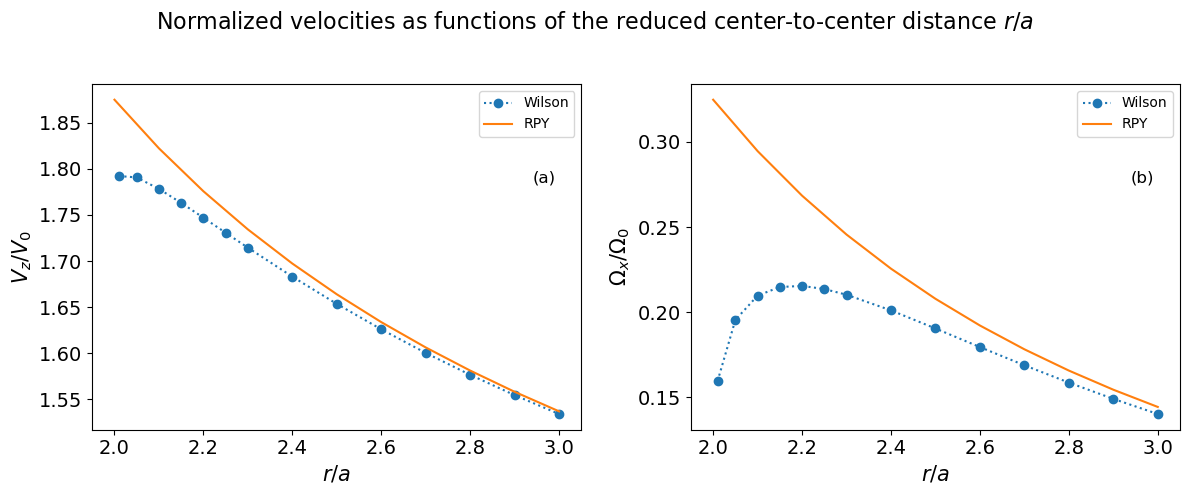

In [1]:
open("velocity_analysis_file.csv", "w").close()

import espressomd
import numpy as np
import json 
import os
import matplotlib.pyplot as plt

def load_vectors(filename="velocity_analysis_file.csv"): 
    vectors = [] 
    
    with open(filename) as f: 
        for line in f: 
            line = line.strip() 
            
            if not line or line.startswith("#"): 
                continue 
        
            vec = np.array([float(x) for x in line.split(",")]) 
            vectors.append(vec) 

    return vectors

# tabulated data from [2014-wilson-jcp]
sWs = np.array([2.01, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0])
vWs = np.array([
1.79223228,
1.79070892,
1.77826951,
1.76311004,
1.74703222,
1.73072508,
1.71452988,
1.68314045,
1.65356957,
1.62599574,
1.6003915,
1.57664602,
1.55461831,
1.53416156
])
wWs = np.array([
0.15960749,
0.195478184,
0.209731929,
0.214756269,
0.215412007,
0.213577673,
0.210224103,
0.201041187,
0.190411103,
0.179481457,
0.16880121,
0.158630515,
0.149081378,
0.140187608
])
 
system = espressomd.System(box_l = [10.0, 10.0, 10.0])
system.time_step = 0.000001
system.cell_system.skin = 1
system.thermostat.set_brownian(kT = 0.0, gamma = 6.0 * np.pi, gamma_rotation = 8.0 * np.pi, seed = 1)
system.integrator.set_brownian_dynamics(2.0)

rs = [2.0 + 0.1 * i for i in range(11)]
 
for r in rs:

    part1 = system.part.add(pos = [0.0, 0.0, 0.0], ext_force = [0.0, 0.0, 1.0])
    part2 = system.part.add(pos = [r, 0.0, 0.0], ext_force = [0.0, 0.0, 1.0])
    part3 = system.part.add(pos = [r/2, (np.sqrt(3)/2) * r, 0], ext_force = [0.0, 0.0, 1.0])
    
    system.integrator.run(1)
    system.part.clear()

vectors = load_vectors() 

V0 = 1.0/(6.0 * np.pi) 
W0 = V0 

VV0s = [(v[2] / V0) for v in vectors]
WW0s = [(np.linalg.norm(v[-3]) / W0) for v in vectors]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

fig.suptitle(
    r"Normalized velocities as functions of the reduced center-to-center distance $r/a$",
    fontsize=16
)

ax = axes[0]
ax.plot(sWs, vWs, "o:", label = "Wilson")
ax.plot(rs, VV0s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$V_z / V_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.90, 0.75, "(a)", transform=ax.transAxes, fontsize=12, va="top")
ax.legend()

ax = axes[1]
ax.plot(sWs, wWs, ":o", label = "Wilson")
ax.plot(rs, WW0s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$\Omega_x/\Omega_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.90, 0.75, "(b)", transform=ax.transAxes, fontsize=12, va="top")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Velocity_analysis_all_in_one_fz.png")

#### Equilateral triangle, one particle with an in-plane orientation

* Ref. [2013-wilson-jcmp], extended by [2025-torres-arxiv]

Equilateral triangle configuration, with in-plane force applied to a single particle, pushing it towards the center of the triangle.

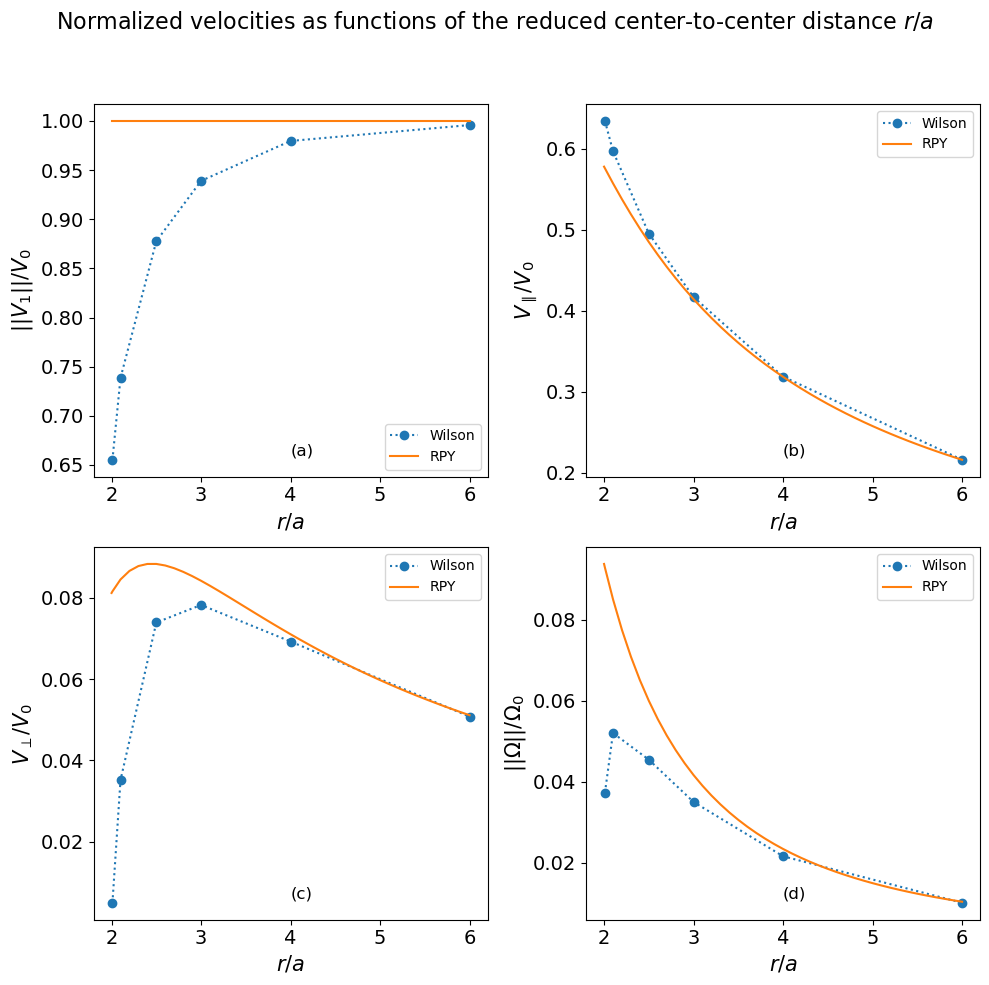

In [1]:
#The mobilities and velocities are no longer dumped in the core



open("velocity_analysis_file.csv", "w").close()

import espressomd
import espressomd.io.writer.vtf
import numpy as np
import json 
import os
import matplotlib.pyplot as plt

def load_vectors(filename="velocity_analysis_file.csv"): 
    vectors = [] 
    
    with open(filename) as f: 
        for line in f: 
            line = line.strip() 
            
            if not line or line.startswith("#"): 
                continue 
        
            vec = np.array([float(x) for x in line.split(",")]) 
            vectors.append(vec) 

    return vectors

# tabulated data from [2014-wilson-jcp]
sWs = np.array([2.01, 2.10, 2.5, 3.0, 4.0, 6.0])
vWs = np.array([
0.65528,
0.73857,
0.87765,
0.93905,
0.97964,
0.99581,
])
wWs = np.array([
0.037336,
0.052035,
0.045466,
0.035022,
0.021634,
0.010159,
])
vWs2 = np.array([
0.63461,
0.59718,
0.49545,
0.41694,
0.31859,
0.21586,
])
vWs3 = np.array([
0.00498,
0.03517,
0.07393,
0.07824,
0.06925,
0.05078,
])
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0])
system.time_step = 0.000001
system.cell_system.skin = 1
system.thermostat.set_brownian(kT = 0.0, gamma = 6.0 * np.pi, gamma_rotation = 8.0 * np.pi, seed = 1)
system.integrator.set_brownian_dynamics(2.0)

rs = [2.0, 2.01, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0]
 
for r in rs:

    part1 = system.part.add(pos = [0.0, 0.0, 0.0])
    part2 = system.part.add(pos = [r, 0.0, 0.0])
    part3 = system.part.add(pos = [r/2, (np.sqrt(3)/2)*r, 0.0], ext_force=[0.0, -6*np.pi, 0.0])

    system.integrator.run(1)
    system.part.clear()

vectors = load_vectors() 
F = 6.0*np.pi
V0 = F/(6.0 * np.pi) 
W0 = V0 

VV0s = [abs(v[7]) / V0 for v in vectors]
WW0s = [np.linalg.norm(v[12:15] - v[9:12])/(2*W0) for v in vectors]
#parallel component of no force particles
VV02s = [abs(v[1] + v[4])/(2*V0) for v in vectors]
#orthogonal component of no force particles
VV03s = [(v[3] - v[0])/(2*V0) for v in vectors]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False)

fig.suptitle(
    r"Normalized velocities as functions of the reduced center-to-center distance $r/a$",
    fontsize=16
)

ax = axes[0, 0]
ax.plot(sWs, vWs, "o:", label = "Wilson")
ax.plot(rs, VV0s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$||V_1||/ V_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.50, 0.05, "(a)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.legend()

ax = axes[0, 1]
ax.plot(sWs, vWs2, "o:", label = "Wilson")
ax.plot(rs, VV02s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$V_\parallel / V_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.50, 0.05, "(b)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.legend()

ax = axes[1, 0]
ax.plot(sWs, vWs3, "o:", label = "Wilson")
ax.plot(rs, VV03s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$V_\perp / V_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.50, 0.05, "(c)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.legend()
 
ax = axes[1, 1]
ax.plot(sWs, wWs, ":o", label = "Wilson")
ax.plot(rs, WW0s, label = "RPY")
ax.set_xlabel("$r/a$", fontsize=15)
ax.set_ylabel(r"$||\Omega||/\Omega_0$", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.text(0.50, 0.05, "(d)", transform=ax.transAxes, fontsize=12, va="bottom")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Velocity_analysis_all_in_one_1force.png")


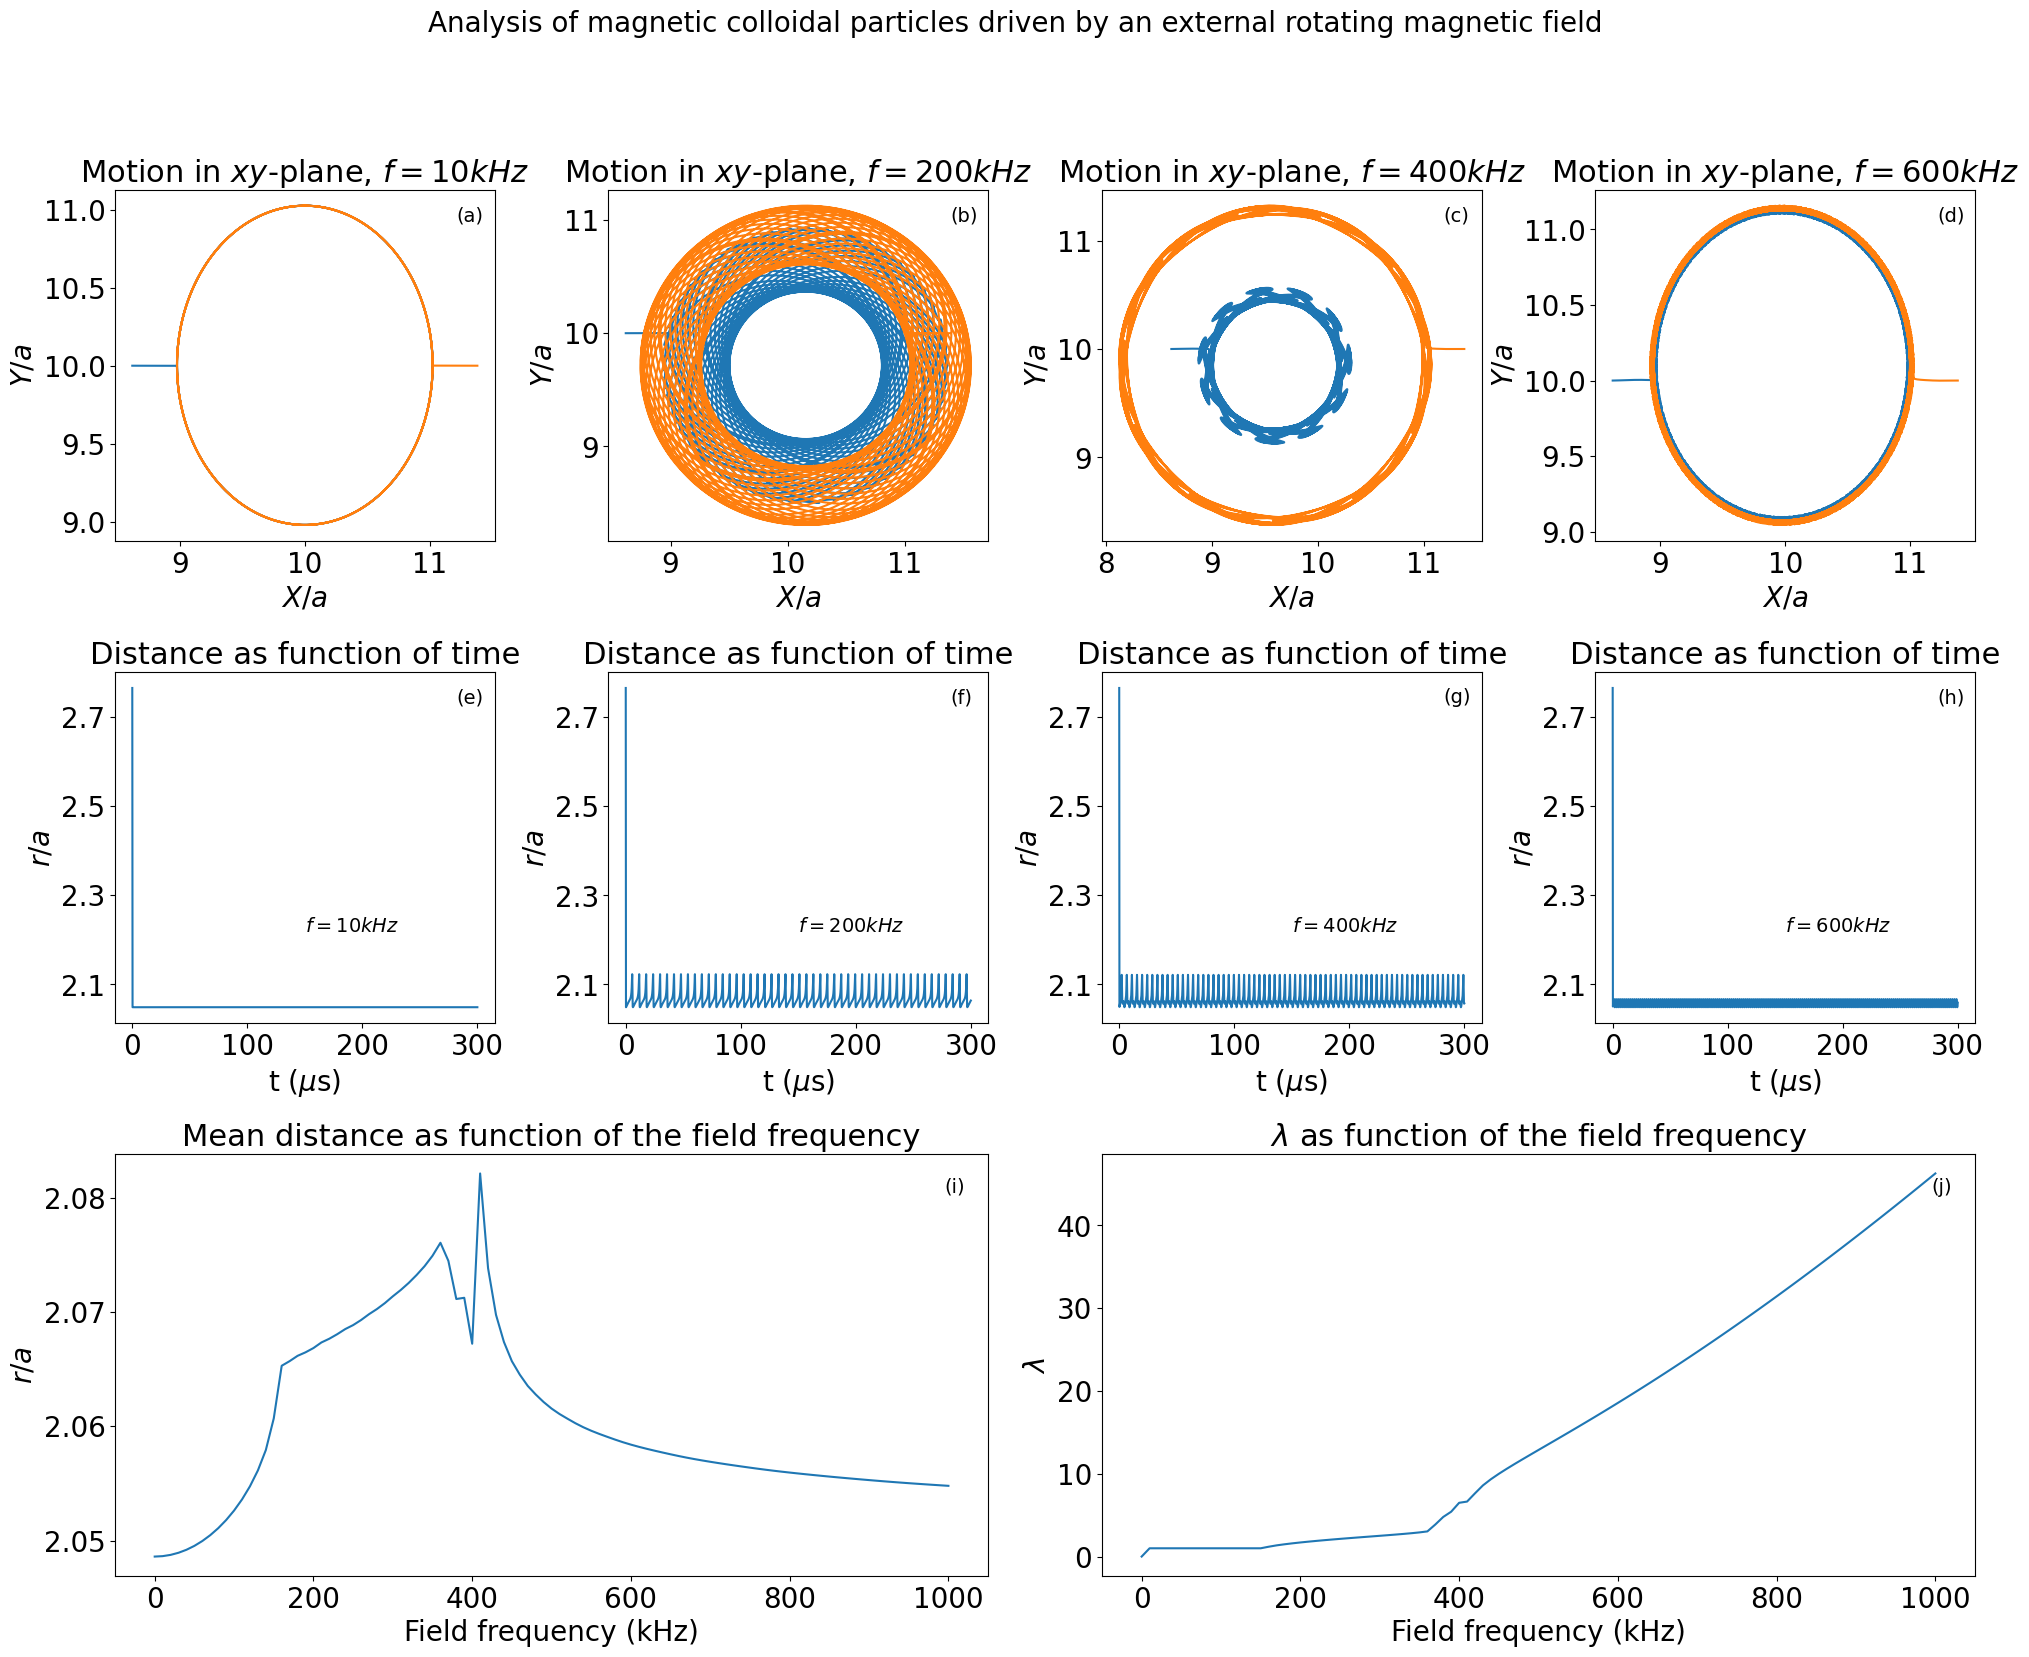

In [1]:
import espressomd
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 0.0, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.0012975 * i for i in range(101)]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.0012975, 0.02595, 0.0519, 0.07785]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])
        
        r1 = np.array(part1.pos)
        r2 = np.array(part2.pos)
        center_to_center_dist.append(np.linalg.norm(r2 - r1))        
        
        axis = (r2 - r1)[:2]
        axis = axis / np.linalg.norm(axis)
        phi = np.arctan2(axis[1], axis[0])
        phi_list.append(phi)
        
    scaled_average_part_dist.append(np.mean(center_to_center_dist))
    
    phi_array = np.unwrap(np.array(phi_list))
    coeff = np.polyfit(time_array, phi_array, 1)
    
    if freq == 0:
        lambda_list.append(0.0)
   
    if freq > 0:
        lambda_list.append((2 * np.pi * freq)/coeff[0])        
    
    if freq in [0.0012975, 0.02595, 0.0519, 0.07785]:
        trajectory_part1_all[freq] = trajectory_part1
        trajectory_part2_all[freq] = trajectory_part2
        center_to_center_dist_all[freq] = center_to_center_dist

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 18))

gs = gridspec.GridSpec(
    3, 4,
    height_ratios=[1, 1, 1.2],
    hspace=0.35,
    wspace=0.30
)

axes = np.empty((2, 4), dtype=object)
for i in range(2):
    for j in range(4):
        axes[i, j] = fig.add_subplot(gs[i, j])

fig.suptitle(
    r"Analysis of magnetic colloidal particles driven by an external rotating magnetic field",
    fontsize=20
)

traj1 = np.array(trajectory_part1_all[0.0012975])
traj2 = np.array(trajectory_part2_all[0.0012975])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 0]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(a)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 10kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.02595])
traj2 = np.array(trajectory_part2_all[0.02595])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 1]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(b)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 200kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.0519])
traj2 = np.array(trajectory_part2_all[0.0519])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 2]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(c)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 400kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.07785])
traj2 = np.array(trajectory_part2_all[0.07785])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 3]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(d)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 600kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.0012975])
time_plot_array = np.array(time) * 0.12975

ax = axes[1, 0]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(e)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 10kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.02595])

ax = axes[1, 1]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(f)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 200kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.0519])

ax = axes[1, 2]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(g)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 400kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.07785])

ax = axes[1, 3]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(h)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 600kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

freq_plot = [10* i for i in range(101)]
freq_array = np.array(freq_plot)
ax_big1 = fig.add_subplot(gs[2, 0:2])
ax_big1.plot(freq_array, scaled_average_part_dist)
ax_big1.text(0.95, 0.90, "(i)", transform=ax_big1.transAxes, fontsize=14, va="bottom")
ax_big1.set_title("Mean distance as function of the field frequency", fontsize = 22)
ax_big1.set_xlabel("Field frequency (kHz)", fontsize=20)
ax_big1.set_ylabel(r"$r/a$", fontsize=20)
ax_big1.tick_params(axis="both", labelsize=20)


ax_big2 = fig.add_subplot(gs[2, 2:4])
ax_big2.plot(freq_array, lambda_list)
ax_big2.text(0.95, 0.90, "(j)", transform=ax_big2.transAxes, fontsize=14, va="bottom")
ax_big2.set_title(r"$\lambda$ as function of the field frequency", fontsize = 22)
ax_big2.set_xlabel("Field frequency (kHz)", fontsize=20)
ax_big2.set_ylabel(r"$\lambda$", fontsize=20)
ax_big2.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_analysis.png")

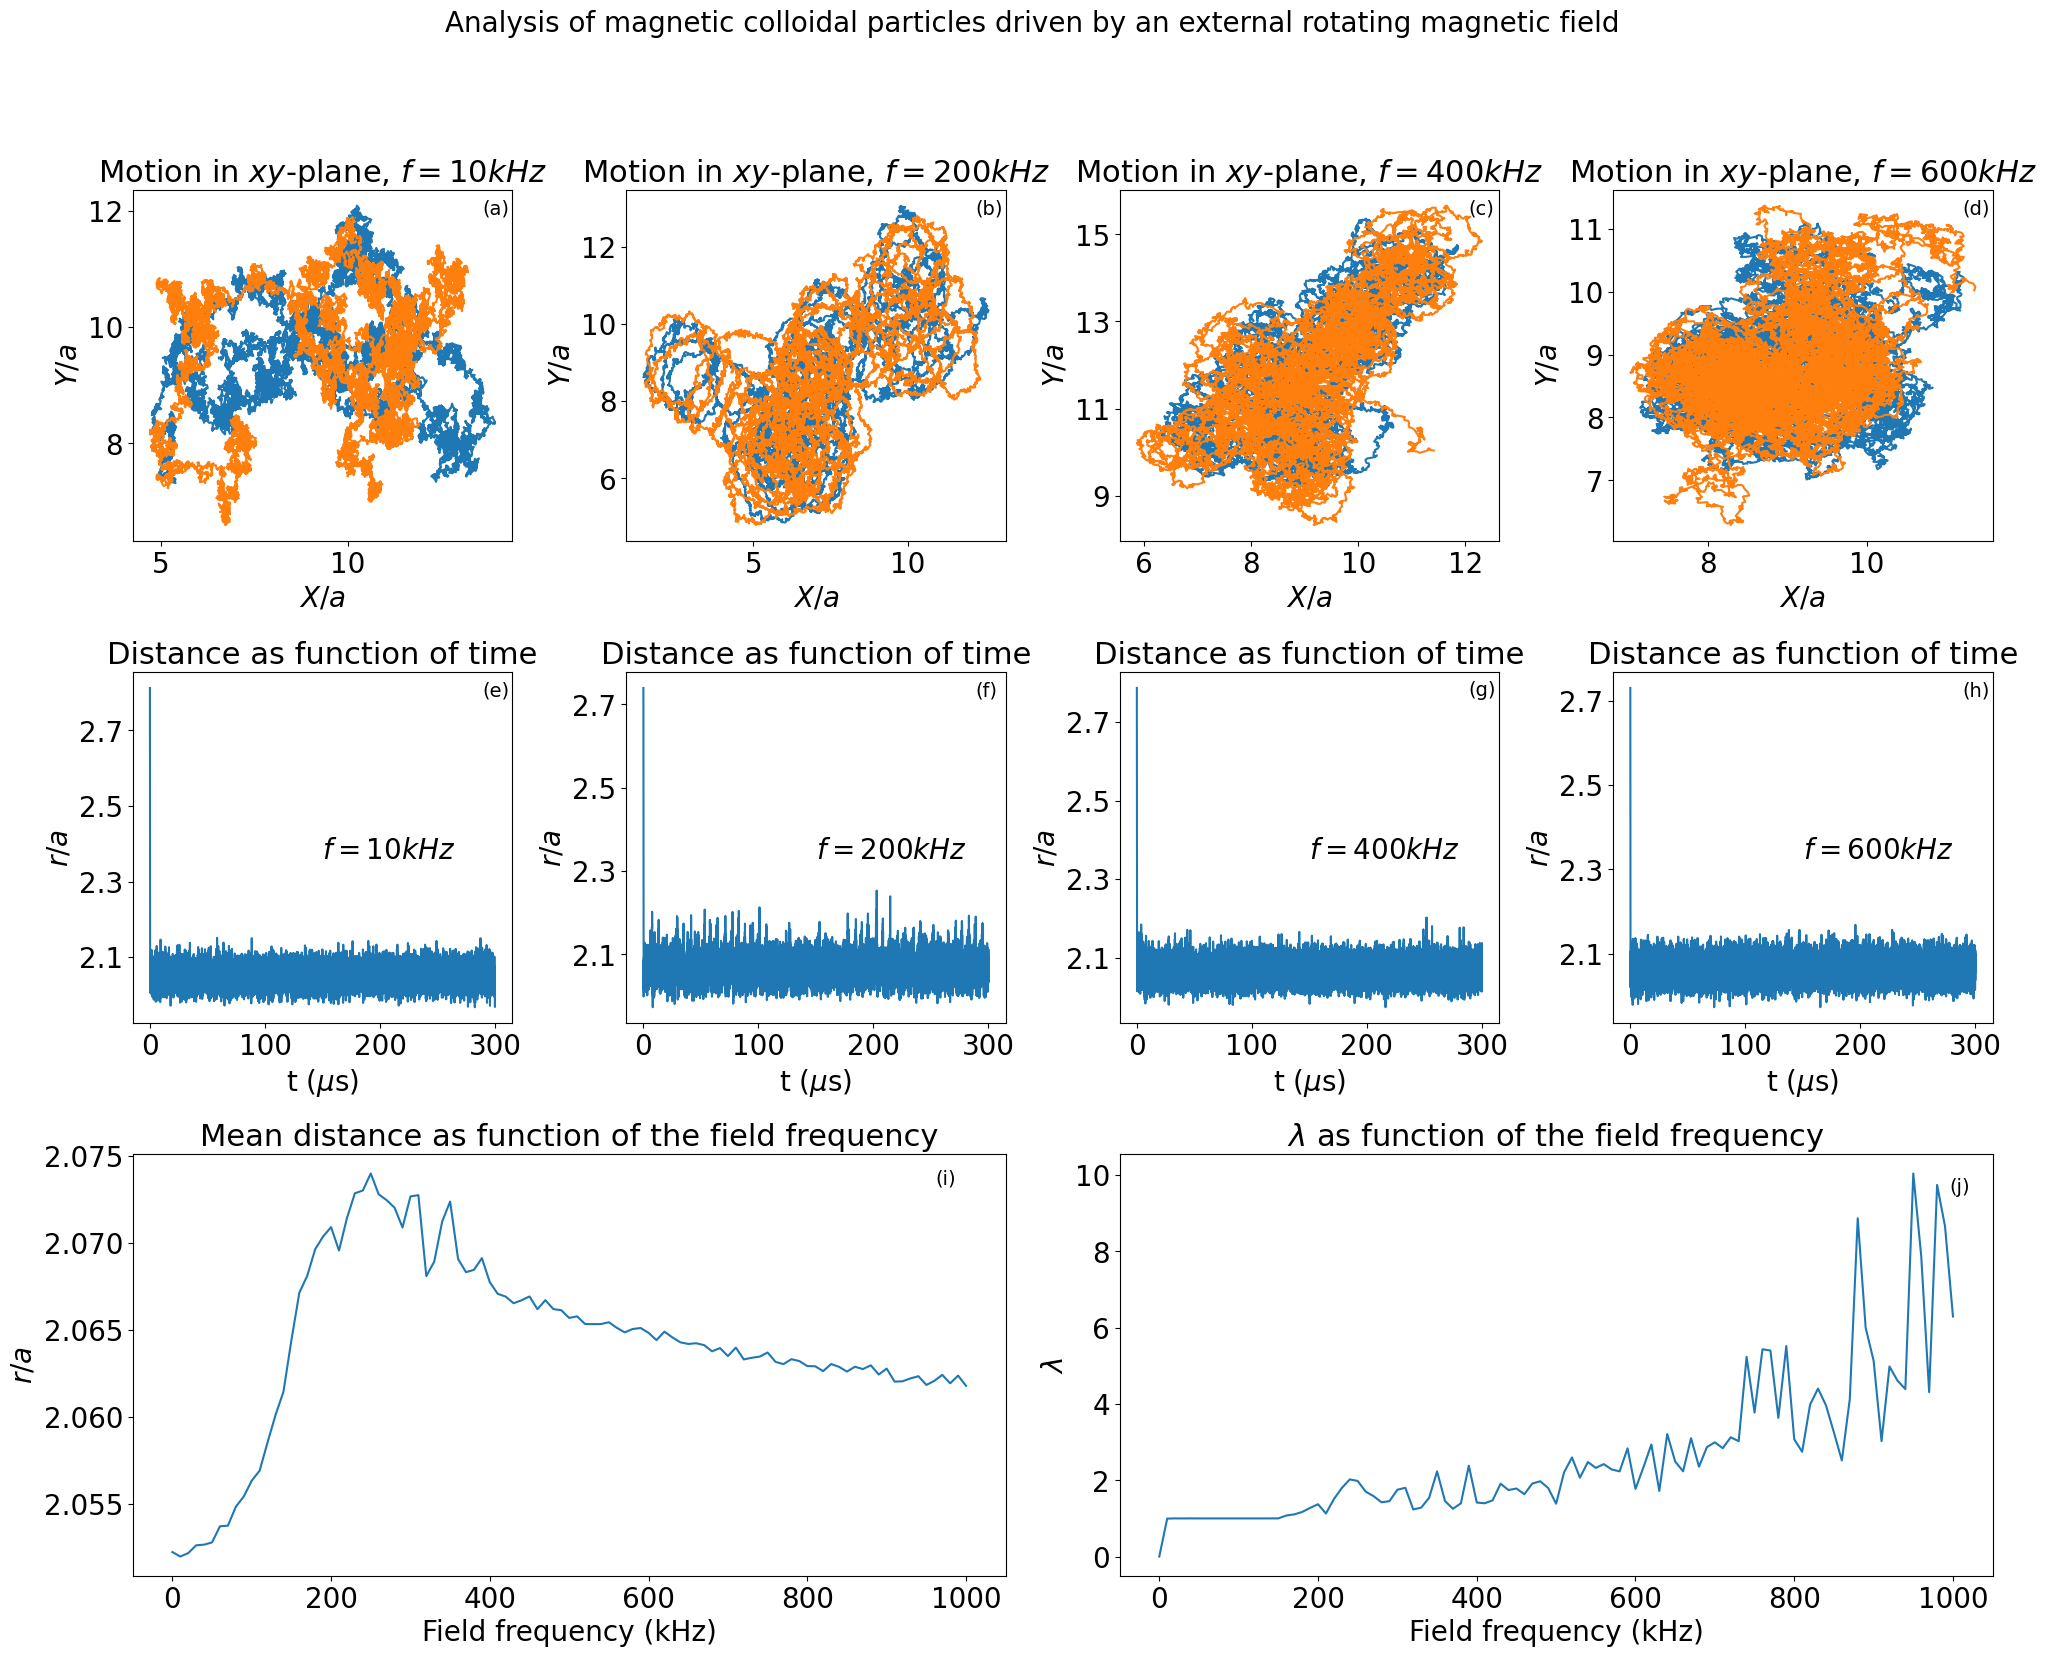

In [1]:
import espressomd
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 1.0, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.0012975 * i for i in range(101)]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.0012975, 0.02595, 0.0519, 0.07785]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])
        
        r1 = np.array(part1.pos)
        r2 = np.array(part2.pos)
        center_to_center_dist.append(np.linalg.norm(r2 - r1))        
        
        axis = (r2 - r1)[:2]
        axis = axis / np.linalg.norm(axis)
        phi = np.arctan2(axis[1], axis[0])
        phi_list.append(phi)
        
    scaled_average_part_dist.append(np.mean(center_to_center_dist))
    
    phi_array = np.unwrap(np.array(phi_list))
    coeff = np.polyfit(time_array, phi_array, 1)
    
    if freq == 0:
        lambda_list.append(0.0)
   
    if freq > 0:
        lambda_list.append((2 * np.pi * freq)/coeff[0])        
    
    if freq in [0.0012975, 0.02595, 0.0519, 0.07785]:
        trajectory_part1_all[freq] = trajectory_part1
        trajectory_part2_all[freq] = trajectory_part2
        center_to_center_dist_all[freq] = center_to_center_dist

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 18))

gs = gridspec.GridSpec(
    3, 4,
    height_ratios=[1, 1, 1.2],
    hspace=0.35,
    wspace=0.30
)

axes = np.empty((2, 4), dtype=object)
for i in range(2):
    for j in range(4):
        axes[i, j] = fig.add_subplot(gs[i, j])

fig.suptitle(
    r"Analysis of magnetic colloidal particles driven by an external rotating magnetic field",
    fontsize=20
)

traj1 = np.array(trajectory_part1_all[0.0012975])
traj2 = np.array(trajectory_part2_all[0.0012975])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 0]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(a)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 10kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.02595])
traj2 = np.array(trajectory_part2_all[0.02595])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 1]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(b)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 200kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.0519])
traj2 = np.array(trajectory_part2_all[0.0519])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 2]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(c)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 400kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.set_yticks([9, 11, 13, 15])
ax.tick_params(axis="both", labelsize=20)

traj1 = np.array(trajectory_part1_all[0.07785])
traj2 = np.array(trajectory_part2_all[0.07785])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

ax = axes[0, 3]
ax.plot(x1, y1)
ax.plot(x2, y2)
ax.text(0.92, 0.92, "(d)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.set_title(r"Motion in $xy$-plane, $f = 600kHz$", fontsize=22)
ax.set_xlabel(r"$X/a$", fontsize=20)
ax.set_ylabel(r"$Y/a$", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.0012975])
time_plot_array = np.array(time) * 0.12975

ax = axes[1, 0]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(e)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 10kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.02595])

ax = axes[1, 1]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(f)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 200kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.0519])

ax = axes[1, 2]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(g)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 400kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

scaled = np.array(center_to_center_dist_all[0.07785])

ax = axes[1, 3]
ax.plot(time_plot_array, scaled)
ax.text(0.92, 0.92, "(h)", transform=ax.transAxes, fontsize=14, va="bottom")
ax.text(0.50, 0.45, r"$f = 600kHz$", transform=ax.transAxes, fontsize=20, va="bottom")
ax.set_title("Distance as function of time", fontsize=22)
ax.set_xlabel(r"t ($\mu$s)", fontsize=20)
ax.set_ylabel(r"$r/a$", fontsize=20)
ax.set_yticks([2.1, 2.3, 2.5, 2.7])
ax.tick_params(axis="both", labelsize=20)

freq_plot = [10* i for i in range(101)]
freq_array = np.array(freq_plot)
ax_big1 = fig.add_subplot(gs[2, 0:2])
ax_big1.plot(freq_array, scaled_average_part_dist)
ax_big1.text(0.92, 0.92, "(i)", transform=ax_big1.transAxes, fontsize=14, va="bottom")
ax_big1.set_title("Mean distance as function of the field frequency", fontsize = 22)
ax_big1.set_xlabel("Field frequency (kHz)", fontsize=20)
ax_big1.set_ylabel(r"$r/a$", fontsize=20)
ax_big1.tick_params(axis="both", labelsize=20)


ax_big2 = fig.add_subplot(gs[2, 2:4])
ax_big2.plot(freq_array, lambda_list)
ax_big2.text(0.95, 0.90, "(j)", transform=ax_big2.transAxes, fontsize=14, va="bottom")
ax_big2.set_title(r"$\lambda$ as function of the field frequency", fontsize = 22)
ax_big2.set_xlabel("Field frequency (kHz)", fontsize=20)
ax_big2.set_ylabel(r"$\lambda$", fontsize=20)
ax_big2.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_analysis_noise.png")


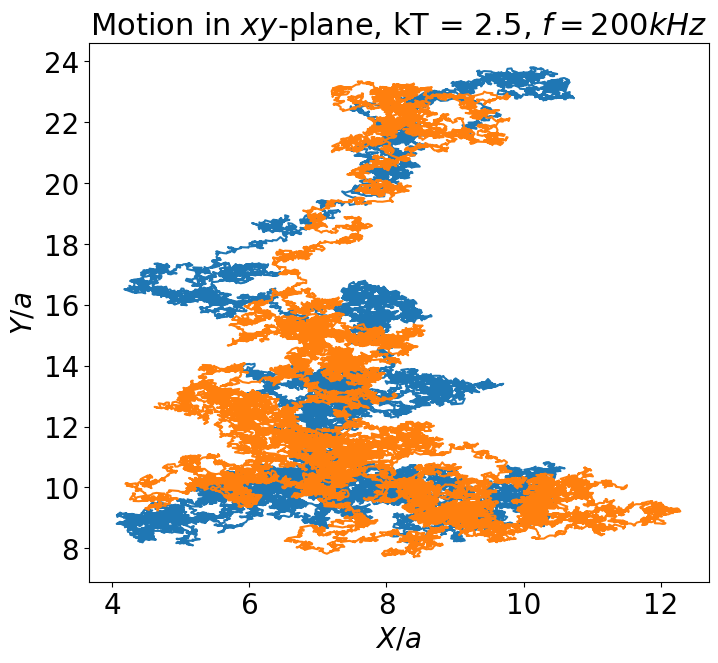

In [1]:
import espressomd
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 2.5, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        
        trajectory_part1.append([float(x) for x in part1.pos])
        trajectory_part2.append([float(x) for x in part2.pos])

import matplotlib.pyplot as plt

traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.figure(figsize=(8, 7))
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 2.5, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_noise_evolution25.png")
    


In [1]:
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 1.0, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.02595]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])

        

import matplotlib.pyplot as plt

traj1 = np.array(trajectory_part1_all[0.02595])
traj2 = np.array(trajectory_part2_all[0.02595])
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.figure(figsize=(8, 7))
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 1.0, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)



plt.savefig("magnetic_noise_evolution1.png")
    


KeyError: 0.02595

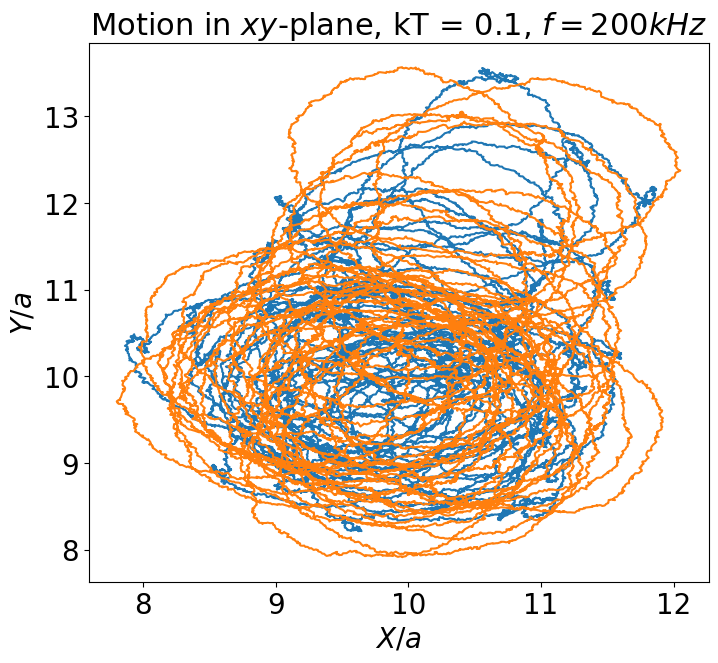

In [1]:
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 0.1, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.02595]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])

import matplotlib.pyplot as plt

traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.figure(figsize=(8, 7))
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 0.1, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_noise_evolution2.png")
    


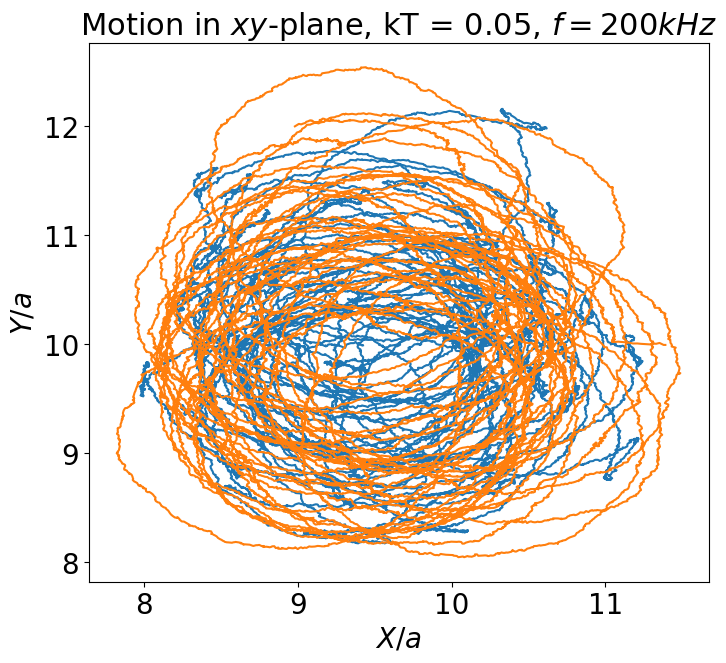

In [1]:
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 0.05, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.02595]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])

import matplotlib.pyplot as plt

traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.figure(figsize=(8, 7))
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 0.05, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_noise_evolution3.png")
    


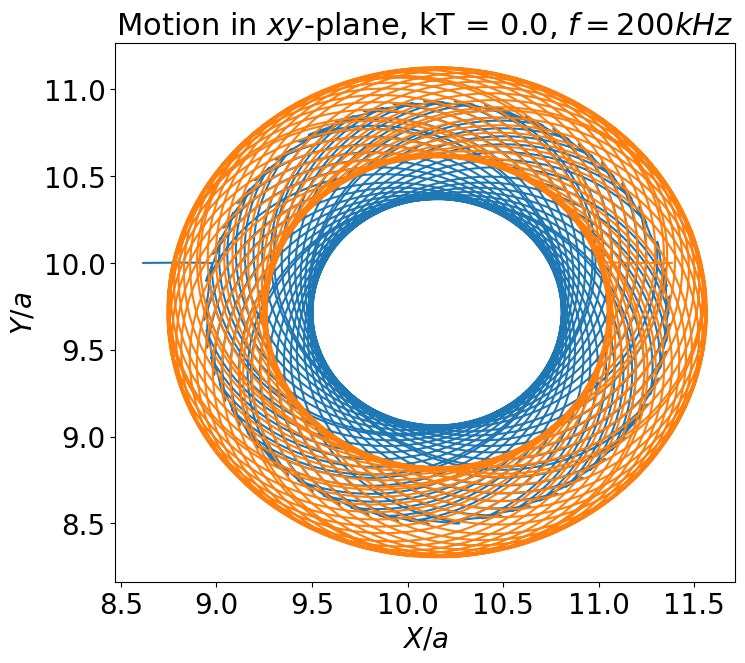

In [1]:
import espressomd
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 0.0, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.02595]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])

import matplotlib.pyplot as plt

traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.figure(figsize=(8, 7))
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 0.0, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_noise_evolution0.png")

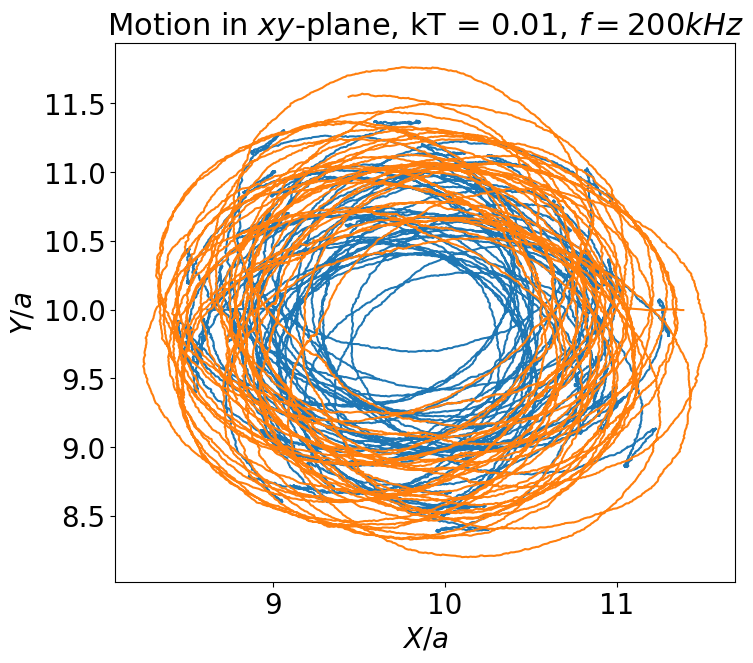

In [1]:
import espressomd.magnetostatics
import numpy as np
 
system = espressomd.System(box_l = [20.0, 20.0, 20.0], periodicity=[False, False, False])

sep = 2.8
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 0.01, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1_all = {}
trajectory_part2_all = {}
center_to_center_dist = []
center_to_center_dist_all = {}
scaled_average_part_dist = []
lambda_list = []

N = 30000

time = [system.time_step * i for i in range(N)]
time_array = np.array(time)
#10kHz
freq_list = [0.02595]
H0 = 97.688

for freq in freq_list: 

    system.time = 0.0
    system.part.clear()

    center = np.array([10.0, 10.0, 10.0])
    #magnetite
    part1 = system.part.add(pos = center + [-sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[1.0, 0.0, 0.0])
    part2 = system.part.add(pos = center + [sep/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip=[2.0, 0.0, 0.0])

    center_to_center_dist = []
    trajectory_part1 = []
    trajectory_part2 = []
    phi_list = []


    for i in range(N):
        
        t = system.time
        omega = 2.0 * np.pi * freq
        coswt = np.cos(omega * t)
        sinwt = np.sin(omega * t)
        B_field = np.array([H0*coswt, H0*sinwt, 0.0])
        
        for p in [part1, part2]:
            
            p.ext_torque = np.cross(p.dip, B_field)
            
        system.integrator.run(1)
        if freq in [0.02595]:
            trajectory_part1.append([float(x) for x in part1.pos])
            trajectory_part2.append([float(x) for x in part2.pos])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)
x1, y1 = traj1[:,0], traj1[:,1]
x2, y2 = traj2[:,0], traj2[:,1]

plt.plot(x1, y1)
plt.plot(x2, y2)
plt.title(r"Motion in $xy$-plane, kT = 0.01, $f = 200kHz$", fontsize=22)
plt.xlabel(r"$X/a$", fontsize=20)
plt.ylabel(r"$Y/a$", fontsize=20)
plt.tick_params(axis="both", labelsize=20)

plt.savefig("magnetic_noise_evolution01.png")

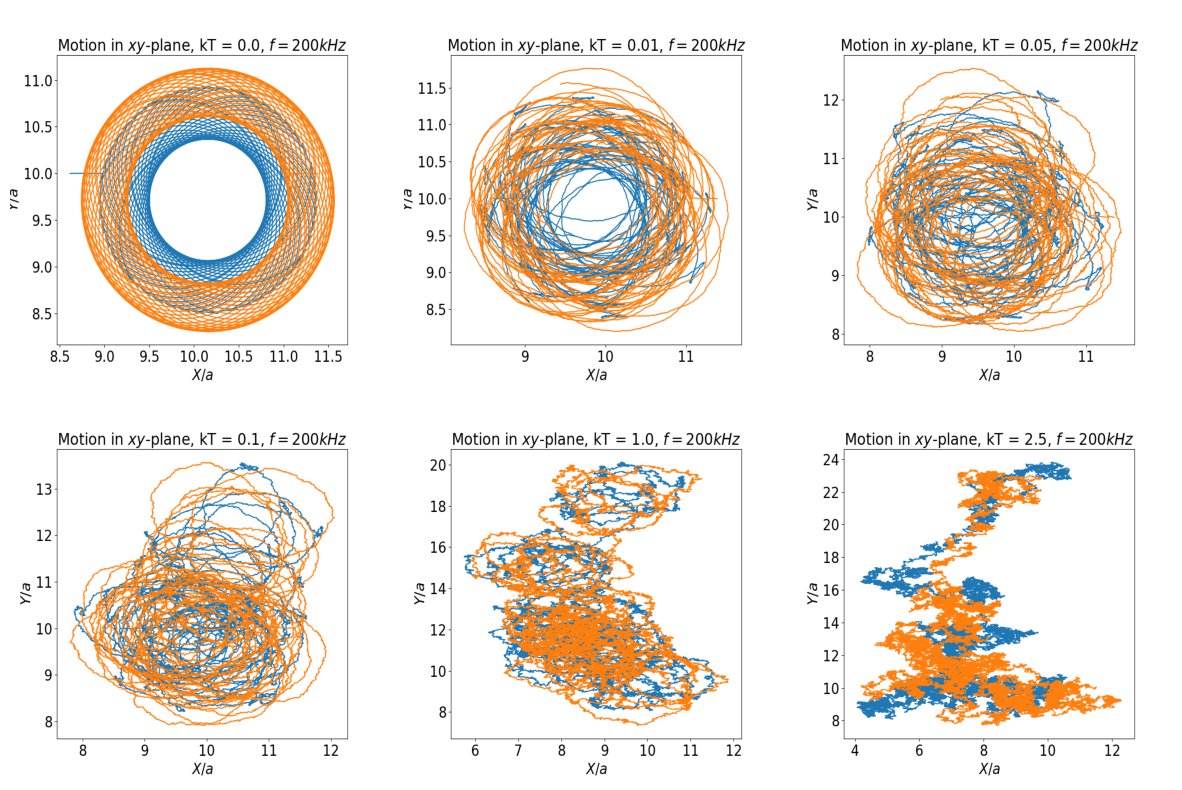

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

imgs = [
    mpimg.imread("magnetic_noise_evolution0.png"),
    mpimg.imread("magnetic_noise_evolution01.png"),
    mpimg.imread("magnetic_noise_evolution3.png"),
    mpimg.imread("magnetic_noise_evolution2.png"),
    mpimg.imread("magnetic_noise_evolution1.png"),
    mpimg.imread("magnetic_noise_evolution25.png"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for ax, img in zip(axes, imgs):
    ax.set_axis_off()
    ax.imshow(img, aspect="auto")

plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.savefig("combined_plots.png", dpi=300)

In [1]:
import espressomd
import espressomd.magnetostatics
import numpy as np
import tidynamics as td
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_fit(t, k, A0):
    return A0 * np.exp(-k*t)
 
system = espressomd.System(box_l = [100.0, 100.0, 100.0], periodicity=[False, False, False])
#10ns
system.time_step = 0.077072
system.cell_system.skin = 0.1
actor = espressomd.magnetostatics.DipolarDirectSumCpu(prefactor=545.593569379)
system.actors.add(actor)
 
"""Triangle Setup"""

part1 = system.part.add(pos = [-90/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip = [1.0, 0.0, 0.0])
part2 = system.part.add(pos = [90/2, 0.0, 0.0], type = 0, rotation=[True, True, True], dip = [1.0, 0.0, 0.0])

"""Setup for Brownian mechanics"""

system.thermostat.set_brownian(kT = 1.0, gamma = 239.98632636541655, gamma_rotation = 319.9817684872221, seed = 1)
system.integrator.set_brownian_dynamics(2.0)
wca = system.non_bonded_inter[0, 0]
wca.wca.set_params(epsilon = 50.0, sigma = 2.0)
 
trajectory_part1 = []
trajectory_part2 = []
orientation_part1 = []
orientation_part2 = []

N=2000000
for i in range(N):
    
    system.integrator.run(1)
    
    trajectory_part1.append([float(x) for x in part1.pos])
    trajectory_part2.append([float(x) for x in part2.pos])
    orientation_part1.append([x for x in part1.dip])
    orientation_part2.append([x for x in part2.dip])
    
traj1 = np.array(trajectory_part1)
traj2 = np.array(trajectory_part2)

orient1 = np.array(orientation_part1)
orient2 = np.array(orientation_part2)

msd1 = td.msd(traj1)
msd2 = td.msd(traj2)
msd_average = (msd1 + msd2)/2
acf1 = td.acf(orient1)
acf2 = td.acf(orient2)
acf_average = (acf1 + acf2)/2

dt_sample = system.time_step
time = np.arange(len(msd_average)) * dt_sample

fit_max_msd = 1000000
fit_max_acf = 15000
coeffs_msd, cov_msd = np.polyfit(time[:fit_max_msd], msd_average[:fit_max_msd], 1, cov=True)
slope = coeffs_msd[0]
slope_err = np.sqrt(cov_msd[0,0])
D_trans = slope / 6
D_trans_err_sim = slope_err / 6
gamma_trans = 1.0/ D_trans
gamma_trans_phys = gamma_trans * 1.3352529517795752e-12
gamma_trans_err = gamma_trans_phys * (D_trans_err_sim/D_trans)
D_trans_phys = 4.14e-21/gamma_trans_phys
D_trans_err = D_trans_phys * (gamma_trans_err/gamma_trans_phys)

popt, pcov = curve_fit(exp_fit, time[:fit_max_acf], acf_average[:fit_max_acf], p0=[0.01, acf_average[0]])
perr = np.sqrt(np.diag(pcov))
k_err, A0_err = perr
D_rot = popt[0]/ 2
D_rot_err_sim = k_err/ 2
gamma_rot = 1.0 / D_rot
gamma_rot_phys = gamma_rot * 5.3410118071183e-28
gamma_rot_err = gamma_rot_phys * (D_rot_err_sim/D_rot)
D_rot_phys = 4.14e-21/gamma_rot_phys
D_rot_err = D_rot_phys * (gamma_rot_err/gamma_rot_phys)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

fig.suptitle(
    r"Mean-square-displacement and autocorrelation function as functions of time",
    fontsize=16
)

time_plot_array = time * 0.12975
ax = axes[0]
ax.plot(time_plot_array, msd_average * 400, label='MSD')
ax.plot(time_plot_array[:fit_max_msd], np.polyval(coeffs_msd, time[:fit_max_msd])*400, '--', label="linear fit", linewidth=3)
ax.set_xlabel(r'$t \ (\mu s)$', fontsize = 14)
ax.set_ylabel(r'$\langle (\Delta r)^{2}(t) \rangle\ (\mathrm{nm^2})$', fontsize = 14)
ax.text(0.90, 0.10, "(a)", transform=ax.transAxes, fontsize=14, va="top")
ax.tick_params(axis="both", labelsize=14)

ax = axes[1]
ax.plot(time_plot_array, acf_average, label='ACF')
ax.plot(time_plot_array[:fit_max_acf], exp_fit(time[:fit_max_acf], popt[0], popt[1]), '--', label="exp fit", linewidth=3)
ax.legend()
ax.tick_params(axis="both", labelsize=14)
ax.text(0.10, 0.10, "(b)", transform=ax.transAxes, fontsize=14, va="top")
ax.set_xlabel(r'$t \ (\mu s)$', fontsize = 14)
ax.set_ylabel(r'$\langle \vec{u}(t) \vec{u}(t+\tau) \rangle$', fontsize = 14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Autocorrelation.png")

print(f"Translational diffusion coefficient D_trans = {D_trans:.5f}")
print(f"Translational friction gamma_trans = {gamma_trans:.5f}")
print(f"Rotational diffusion coefficient D_rot = {D_rot:.5f}")
print(f"Rotational friction gamma_rot = {gamma_rot:.5f}")
print(f"Translational diffusion coefficient D_trans_phys = {D_trans_phys:.5e}")
print(f"Translational friction gamma_trans_phys = {gamma_trans_phys:.5e}")
print(f"Rotational diffusion coefficient D_rot_phys = {D_rot_phys:.5e}")
print(f"Rotational friction gamma_rot_phys = {gamma_rot_phys:.5e}")
print(f"Translational diffusion coefficient D_trans_err = {D_trans_err:.2e}")
print(f"Translational friction gamma_trans_err = {gamma_trans_err:.2e}")
print(f"Rotational diffusion coefficient D_rot_err = {D_rot_err:.2e}")
print(f"Rotational friction gamma_rot_err = {gamma_rot_err:.2e}")



ModuleNotFoundError: No module named 'tidynamics'